In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

# Reading chains

In [32]:
blind = True
fname_blind = '../output/blind-metacal/des-y3-2pt-blind-metacal-simcov.txt'
# 2pt only
blind_2pt = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal/des-y3-2pt-blind-metacal-simcov.txt', to_mcsamples=True, blind=blind, fname_mean=fname_blind)
# blind_2pt = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal/des-y3-2pt-blind-metacal.txt', to_mcsamples=True, blind=True)
# map3 only
blind_map3 = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal/des-y3-map3-blind-metacal.txt', to_mcsamples=True, blind=blind, fname_mean=fname_blind)
# joint all
blind_joint_all = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal/des-y3-2pt-map3-all-blind-metacal.txt', to_mcsamples=True, blind=blind, fname_mean=fname_blind)
# joint auto only
blind_joint_auto = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal/des-y3-2pt-map3-auto.txt', to_mcsamples=True, blind=blind, fname_mean=fname_blind)
# joint auto 334 344
blind_joint_auto_334_344 = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal/des-y3-2pt-map3-auto-334-344.txt', to_mcsamples=True, blind=blind, fname_mean=fname_blind)


Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in
Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in
Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in
Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in
Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in


## 2pt, map3 and joint

<Figure size 600x600 with 0 Axes>

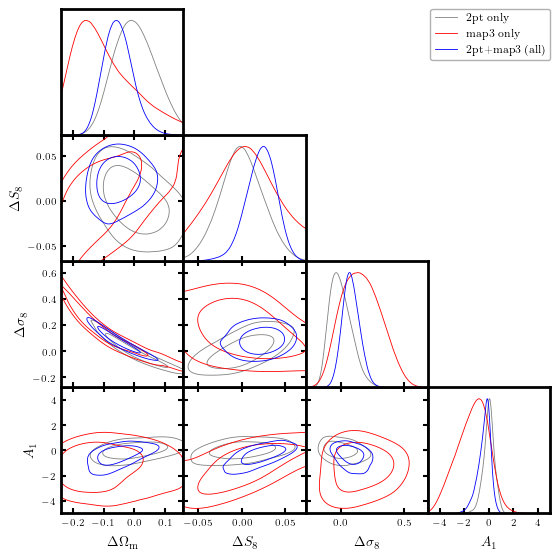

In [33]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([blind_2pt, blind_map3, blind_joint_all], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt only', 'map3 only',  '2pt+map3 (all)'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'blue'])
plt.show()

# increase in constraining power from 2pt to 2pt+map3(all)

<Figure size 600x600 with 0 Axes>

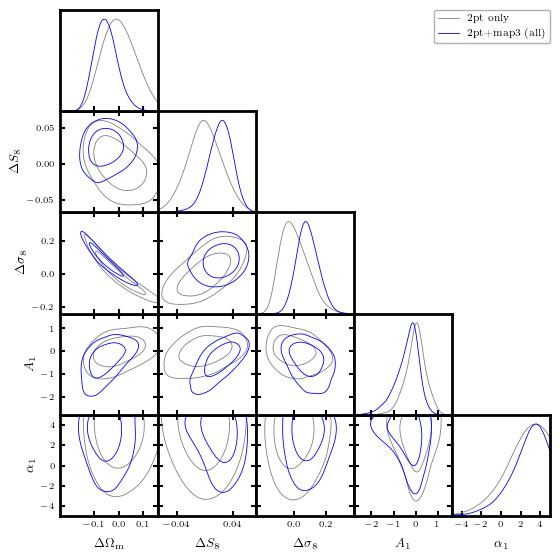

In [18]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([blind_2pt, blind_joint_all], ['om', 's8', 'sig8', 'a1', 'alpha1'], filled=False, \
    legend_labels=['2pt only','2pt+map3 (all)'], legend_loc='upper right', 
    contour_colors=['gray', 'blue'])
plt.show()

In [19]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint = utils.FoM_from_samples_names(blind_joint_all, ['om', 's8'])

print(fom_2pt, fom_joint)
print(fom_joint/fom_2pt)

699.7885268782126 1226.8361921006829
1.7531527668417959


# 2pt to 2pt+map3(auto only)

<Figure size 600x600 with 0 Axes>

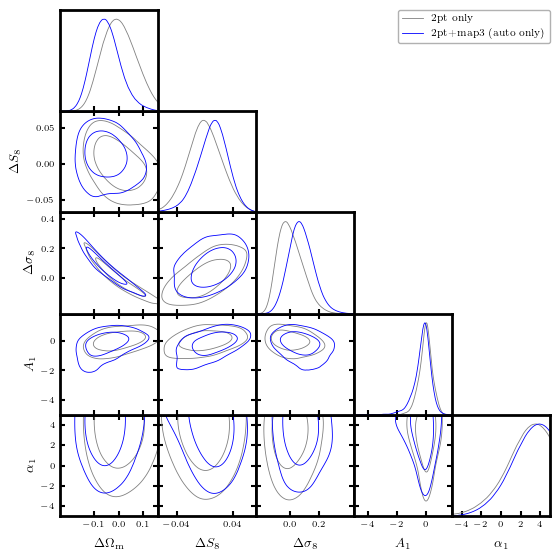

In [20]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([blind_2pt, blind_joint_auto], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt only','2pt+map3 (auto only)'], legend_loc='upper right', 
    contour_colors=['gray', 'blue'])
plt.show()

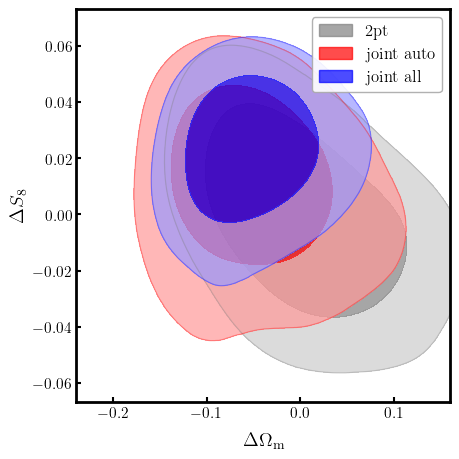

In [37]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([blind_2pt, blind_joint_auto, blind_joint_all], 'om', 's8', filled=True, 
    colors=['gray', 'red', 'blue'], alphas=[0.7, 0.7, 0.7])
g.add_legend(['2pt', 'joint auto', 'joint all'], legend_loc='upper right')

In [22]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(blind_joint_auto, ['om', 's8'])

print(fom_2pt, fom_joint_auto)
print(fom_joint_auto/fom_2pt)

699.7885268782126 821.5527004353195
1.174001385961988


# 2pt vs 2pt+map3(auto+334+344)

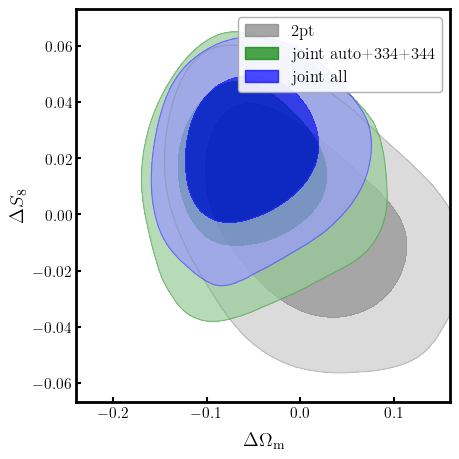

In [38]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([blind_2pt, blind_joint_auto_334_344, blind_joint_all], 'om', 's8', filled=True, 
    colors=['gray', 'green', 'blue'], alphas=[0.7, 0.7, 0.7])
g.add_legend(['2pt', 'joint auto+334+344', 'joint all'], legend_loc='upper right')

In [24]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto_334_344 = utils.FoM_from_samples_names(blind_joint_auto_334_344, ['om', 's8'])

print(fom_2pt, fom_joint_auto_334_344)
print(fom_joint_auto_334_344/fom_2pt)

699.7885268782126 981.5691416074584
1.4026653823352628


### Summary in one plot

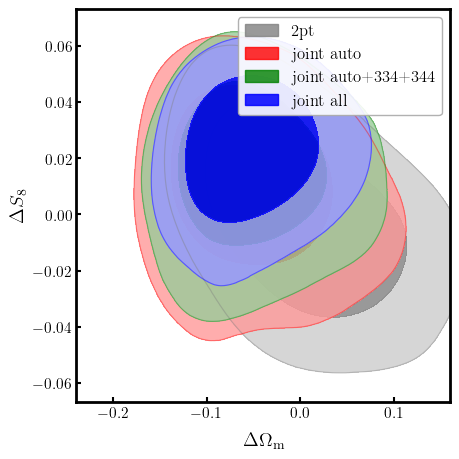

In [25]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([blind_2pt, blind_joint_auto, blind_joint_auto_334_344, blind_joint_all], 'om', 's8', filled=True, 
    colors=['gray', 'red', 'green', 'blue'], alphas=[0.8, 0.8, 0.8])
g.add_legend(['2pt', 'joint auto', 'joint auto+334+344', 'joint all'], legend_loc='upper right')

In [26]:
import pandas as pd

fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(blind_joint_auto, ['om', 's8'])
fom_joint_auto_334_344 = utils.FoM_from_samples_names(blind_joint_auto_334_344, ['om', 's8'])
fom_joint_all = utils.FoM_from_samples_names(blind_joint_all, ['om', 's8'])

data = {'Analysis': ['2pt only', '2pt+map3 (auto only)', '2pt+map3 (auto+334+344)', '2pt+map3 (all)'],
    'FoM': [fom_2pt, fom_joint_auto, fom_joint_auto_334_344, fom_joint_all],
    'Ratio to 2pt': [1, fom_joint_auto/fom_2pt, fom_joint_auto_334_344/fom_2pt, fom_joint_all/fom_2pt]}

df = pd.DataFrame(data)
df

,Analysis,FoM,Ratio to 2pt
0,2pt only,699.788527,1.000000
1,2pt+map3 (auto only),821.552700,1.174001
2,2pt+map3 (auto+334+344),981.569142,1.402665
3,2pt+map3 (all),1226.836192,1.753153


# Theory vs Data vector at Signal level

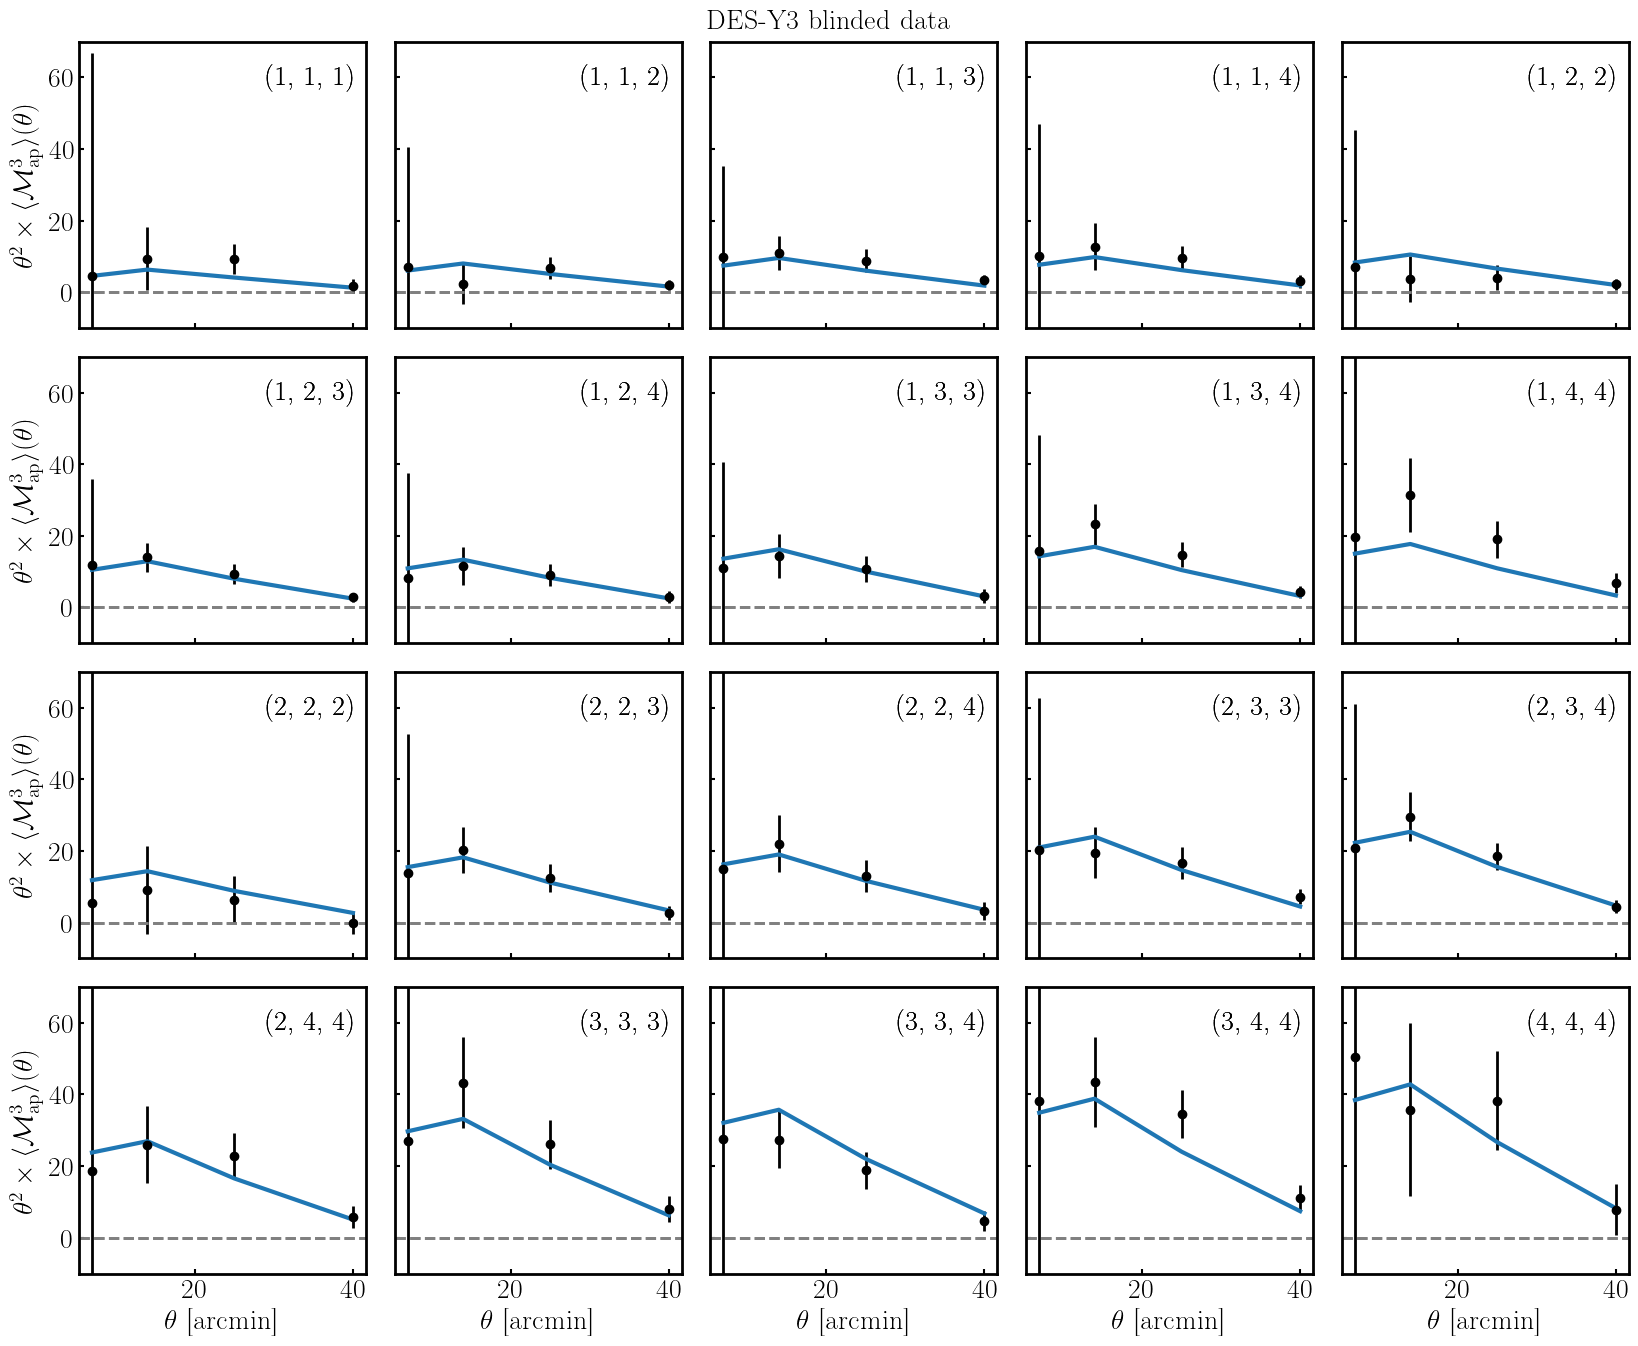

In [4]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/real_map3_desy3_blind.fits')
line_args = dict(color='k')
fig, axes = thpt.plot2d(4, 5, figsize=(20, 16), title='DES-Y3 blinded data', **line_args)
thpt_bf = threepoint.ThreePointDataClass.from_fits('../data/dv/real_map3_desy3_blind_BESTFIT.fits')
line_args = dict(color='C0', lw=3)
fig, axes = thpt_bf.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args)
fig.savefig('../plots/signal-blind-map3-vs-bestfit.pdf', bbox_inches='tight')

## Testing chi2 values as a function of scale and z

In [5]:
for Rmin in [7,14,25, 40]:
    # 
    data = thpt.get_signal()
    theo = thpt_bf.get_signal()
    diff = data - theo
    cov  = thpt.get_covariance()
    R    = thpt.get_t_bin()[0]
    #
    sel  = R>=Rmin
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (400-diff.size-2)/(400-1)
    icov = np.linalg.inv(cov) * f
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

33.698/80=0.421
20.822/60=0.347
11.294/40=0.282
4.897/20=0.245


In [6]:
for Rmax in [7,14,25, 40]:
    # 
    data = thpt.get_signal()
    theo = thpt_bf.get_signal()
    diff = data - theo
    cov  = thpt.get_covariance()
    R    = thpt.get_t_bin()[0]
    #
    sel  = R<=Rmax
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (400-diff.size-2)/(400-1)
    icov = np.linalg.inv(cov) * f
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

0.045/20=0.002
9.953/40=0.249
20.666/60=0.344
33.698/80=0.421


In [7]:
for i in range(20):
    # 
    data = thpt.get_signal()
    theo = thpt_bf.get_signal()
    diff = data - theo
    cov  = thpt.get_covariance()
    # print(np.unique(R))
    #
    sel  = np.arange(4*i, 4*(i+1), 1)
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (400-diff.size-2)/(400-1)
    icov = np.linalg.inv(cov)
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

1.066/4=0.267
1.409/4=0.352
0.523/4=0.131
0.510/4=0.127
0.985/4=0.246
0.118/4=0.029
0.221/4=0.055
0.158/4=0.040
1.115/4=0.279
2.291/4=0.573
0.509/4=0.127
0.287/4=0.072
0.155/4=0.039
1.397/4=0.349
0.645/4=0.161
0.954/4=0.239
0.624/4=0.156
0.817/4=0.204
1.312/4=0.328
1.120/4=0.280


In [18]:
data = thpt.get_signal()
theo = thpt_bf.get_signal()
diff = data - theo
cov  = thpt.get_covariance()
cov  = np.diag(np.diag(cov)) # Take only diagonal
R    = thpt.get_t_bin()[0]
# 
f = (400-diff.size-2)/(400-1)
icov = np.linalg.inv(cov) * f
chi2 = diff.dot(icov).dot(diff)
dof  = diff.size
print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

12.975/80=0.162


In [19]:
data = thpt.get_signal()
theo = thpt_bf.get_signal()
diff = data - theo
# cov  = thpt.get_covariance()
cov = np.loadtxt('../data/meas4k/cov_2pcf_map3_n380_noise0.dat')[400:, 400:]
R    = thpt.get_t_bin()[0]
# 
f = (400-diff.size-2)/(400-1)
icov = np.linalg.inv(cov) * f
chi2 = diff.dot(icov).dot(diff)
dof  = diff.size
print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

12.857/80=0.161
